In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [16]:
MOMENTUM_TOF = '/Users/user/data/research/proton-deuteron/bruno/root/momentum_tof.csv'
MASS = '/Users/user/data/research/proton-deuteron/csv/picky+match.csv'

In [17]:
df = pd.read_csv(MOMENTUM_TOF); print(df.columns)
mass = pd.read_csv(MASS); print(mass.columns)

Index(['run', 'subrun', 'event', 'momentum', 'tof'], dtype='object')
Index(['run', 'subrun', 'event', 'p', 'm', 'beamline_mass'], dtype='object')


2130

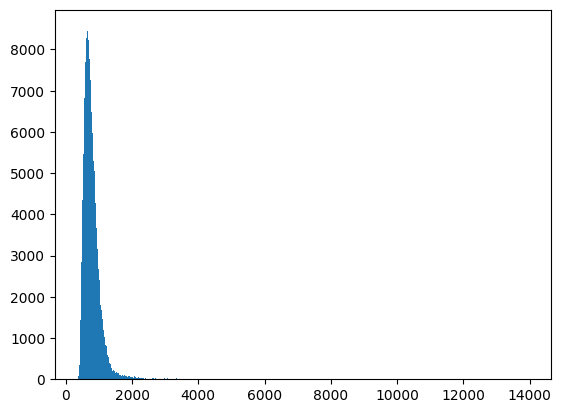

In [8]:
a = plt.hist(df['momentum'], bins='auto')
len(a[0])

299

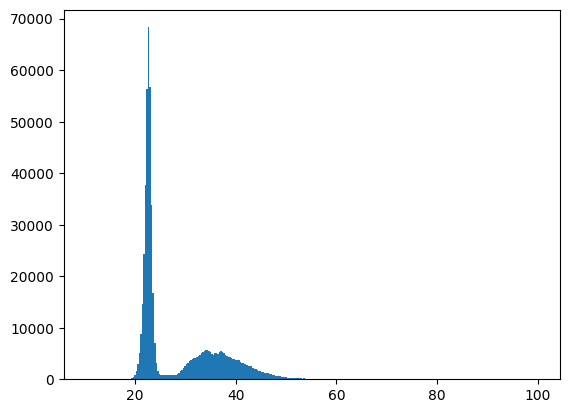

In [9]:
b = plt.hist(df['tof'], bins='auto')
len(b[0])

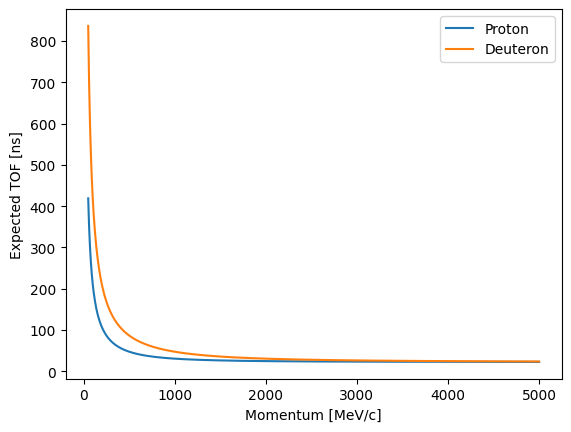

In [10]:
tau_l = 22.30  # ns
alpha = 1.0
delta_tau = 0.0  # ns

# masses (MeV/c^2)
m_p = 938.3
m_d = 1875.6

# momentum range (MeV/c)
p = np.linspace(50, 5000, 1000)  # from 50 to 5000 MeV/c

def tof(p, m, tau_l, alpha=1.0, delta_tau=0.0):
    return tau_l * np.sqrt(1 + (m/(alpha*p))**2) - delta_tau

plt.plot(p, tof(p, m_p, tau_l, alpha, delta_tau), label="Proton")
plt.plot(p, tof(p, m_d, tau_l, alpha, delta_tau), label="Deuteron")
plt.xlabel("Momentum [MeV/c]")
plt.ylabel("Expected TOF [ns]")
plt.legend()
plt.show()

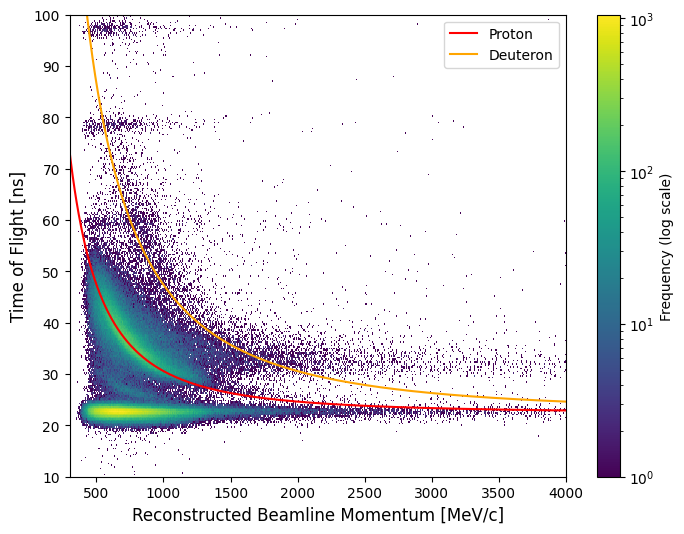

In [11]:
plt.figure(figsize=(8, 6))
h = plt.hist2d(df['momentum'], df['tof'], bins=[2130, 299], norm=LogNorm(), cmap='viridis')
plt.plot(p, tof(p, m_p, tau_l, alpha, delta_tau), label="Proton", color='red')
plt.plot(p, tof(p, m_d, tau_l, alpha, delta_tau), label="Deuteron", color='orange')
plt.xlabel('Reconstructed Beamline Momentum [MeV/c]', fontsize=12)
plt.ylabel('Time of Flight [ns]', fontsize=12)
plt.ylim(10, 100)
plt.xlim(300, 4000)
# plt.title('Heatmap: Maxdiff vs Length of cluster')
plt.colorbar(label='Frequency (log scale)')
plt.legend()

plt.show()


In [14]:
m_d = 1875.6
tau_l = 22.30  # ns

def tof_expected(p, m, tau_l):
    return tau_l * np.sqrt(1 + (m/p)**2)

# tolerance band (adjust to your timing resolution)
dt = 0.3  # ns

df['tof_exp_deuteron'] = tof_expected(df['momentum'], m_d, tau_l)
mask = np.abs(df['tof'] - df['tof_exp_deuteron']) < dt
deuterons = df[mask].reset_index(drop=True)

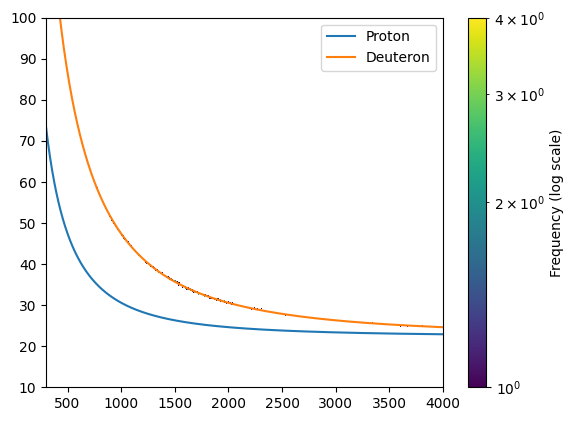

In [15]:
plt.figure()
h = plt.hist2d(deuterons['momentum'], deuterons['tof'], bins=[2130, 299], norm=LogNorm(), cmap='viridis')
plt.plot(p, tof(p, m_p, tau_l, alpha, delta_tau), label="Proton")
plt.plot(p, tof(p, m_d, tau_l, alpha, delta_tau), label="Deuteron")
# plt.xlabel('Max Normalised ADC Difference')
# plt.ylabel('Length of track (in wires)')
plt.ylim(10, 100)
plt.xlim(300, 4000)
# plt.title('Heatmap: Maxdiff vs Length of cluster')
plt.colorbar(label='Frequency (log scale)')
plt.legend()
plt.show()

# Beamline Mass, Momentum & Length

In [60]:
allclusters = pd.read_pickle("/Users/user/data/research/proton-deuteron/csv/allclusters.pkl")

In [106]:
all = pd.merge(df,
                 mass, 
                 on=['run', 'subrun', 'event'],
                 how='inner')

clusters = pd.merge(all,
               allclusters,
               on = ['run', 'subrun', 'event'],
               how = 'inner')

all.columns

Index(['run', 'subrun', 'event', 'momentum', 'tof', 'p', 'm', 'beamline_mass'], dtype='object')

In [107]:
picky = all[(all['p'] == 1) & (all['beamline_mass'] > 600) & (all['beamline_mass'] < 2750)]

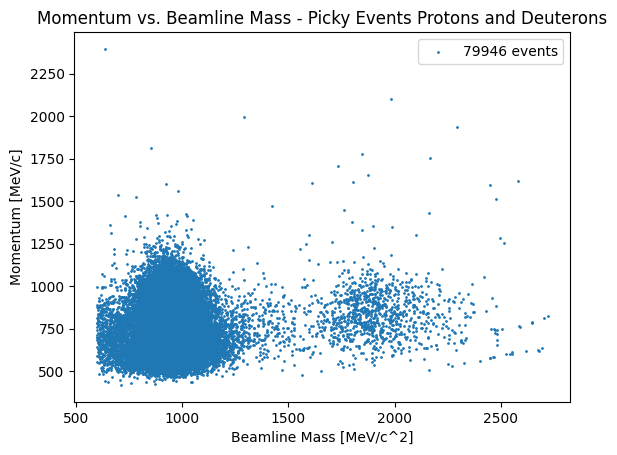

In [108]:
plt.scatter(picky['beamline_mass'].values, picky['momentum'].values, s=1, label=(f'{len(picky)} events'))
plt.ylabel('Momentum [MeV/c]')
plt.xlabel('Beamline Mass [MeV/c^2]')
plt.title('Momentum vs. Beamline Mass - Picky Events Protons and Deuterons')
plt.legend()

In [109]:
plot = clusters[(clusters['plane'] == 'collection') & (clusters['p'] == 1) & (clusters['beamline_mass'] > 1500) & (clusters['beamline_mass'] < 2750)]

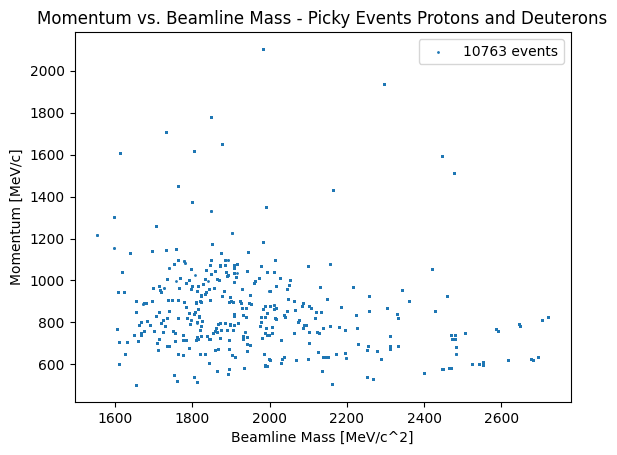

In [110]:
plt.scatter(plot['beamline_mass'].values, plot['momentum'].values, s=1, label=(f'{len(plot)} events'))
plt.ylabel('Momentum [MeV/c]')
plt.xlabel('Beamline Mass [MeV/c^2]')
plt.title('Momentum vs. Beamline Mass - Picky Events Protons and Deuterons')
plt.legend()

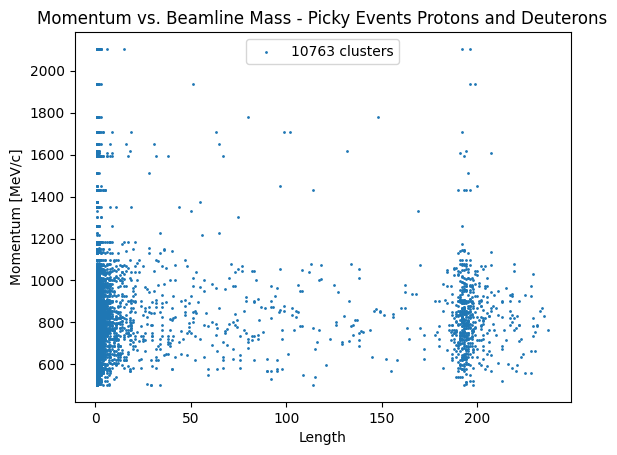

In [114]:
plt.scatter(plot['height'].values, plot['momentum'].values, s=1, label=(f'{len(plot)} clusters'))
plt.ylabel('Momentum [MeV/c]')
plt.xlabel('Length')
plt.title('Momentum vs. Beamline Mass - Picky Events Protons and Deuterons')
plt.legend()